# Exercise 7: Denoising Diffusion Probabilistic Models
## Submission date: 11/07/2026, 23:59.

Submitted by:

 **Amir Ammar 205744873**

 **Baruh Riss 318739174**


<font color='red'>Before submission, please make sure that all the plots and results are present as a colab notebook file</font>

## Configurations and initializations

This section loads libraries and configurations for various tasks for this course

In [7]:
## Standard libraries
import os
import math
import numpy as np
import pandas as pd
from collections import defaultdict

## Imports for plotting
import matplotlib.pyplot as plt
plt.set_cmap('cividis')
import seaborn as sns

## Progress bar
from tqdm.notebook import tqdm

## PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim
# Torchvision
import torchvision
from torchvision.datasets import MNIST
from torchvision import transforms

# Path to the folder where the datasets are/should be downloaded (e.g. MNIST)
DATASET_PATH = "../data"

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Fetching the device that will be used throughout this notebook
device = torch.device("cpu") if not torch.cuda.is_available() else torch.device("cuda")
print("Using device", device)

Using device cuda


<Figure size 640x480 with 0 Axes>

In [29]:
def scale(sample):
    return 2 * sample - 1

# Transformations applied on each image => only make them a tensor
transform = transforms.Compose([transforms.ToTensor(), scale])

# Loading the training dataset. We need to split it into a training and validation part
train_dataset = MNIST(root=DATASET_PATH, train=True, transform=transform, download=True)

train_set, val_set = torch.utils.data.random_split(train_dataset, [50000, 10000])

# Loading the test set
test_set = MNIST(root=DATASET_PATH, train=False, transform=transform, download=True)

# We define a set of data loaders that we can use for various purposes later.
train_loader = data.DataLoader(train_set, batch_size=128, shuffle=True,  drop_last=True)
val_loader   = data.DataLoader(val_set,   batch_size=128, shuffle=False, drop_last=True)
test_loader  = data.DataLoader(test_set,  batch_size=128, shuffle=False, drop_last=True)

print('Train size:', len(train_loader.dataset))
print('Validation size:', len(val_loader.dataset))
print('Test size:', len(test_loader.dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 479kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.51MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.2MB/s]

Train size: 50000
Validation size: 10000
Test size: 10000


In [30]:
def show_tensor_image(img):
    reverse_transforms = transforms.Compose([
        transforms.Lambda(lambda t: (t + 1) / 2),
        transforms.Lambda(lambda t: torch.minimum(torch.tensor([1]), t)),
        transforms.Lambda(lambda t: torch.maximum(torch.tensor([0]), t)),
        transforms.ToPILImage(),
    ])
    plt.imshow(reverse_transforms(img))

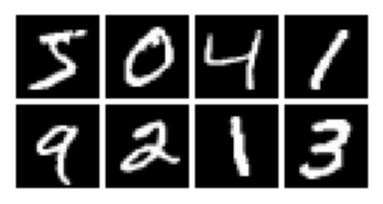

In [31]:
def show_imgs(imgs, nrows=1):
    ncols = len(imgs) // nrows

    imgs = torch.stack(imgs) if isinstance(imgs, list) else imgs        # T, img, ch, size, size or img, ch, size, size

    imgs = imgs.unsqueeze(0) if imgs.ndim == 4 else imgs                # T, img, ch, size, size
    imgs = imgs.transpose(1, 0)                                         # img, T, ch, size, size
    imgs = imgs.reshape((-1,) + imgs.shape[2:])                         # img * T, ch, size, size

    plt.figure(figsize=(ncols * 1.2, nrows * 1.2))
    grid = torchvision.utils.make_grid(imgs.cpu(), nrow=ncols, pad_value=128)
    show_tensor_image(grid.detach().cpu())

    plt.axis('off')
    plt.show()
    plt.close()

show_imgs([train_dataset[i][0] for i in range(8)], nrows=2)

## Components & Architecture

In [ ]:
class EmbedBlock(nn.Module):
    def __init__(self, input_dim, emb_dim):
        super(EmbedBlock, self).__init__()
        self.input_dim = input_dim
        layers = [
            nn.Linear(input_dim, emb_dim),
            nn.ReLU(),
            nn.Linear(emb_dim, emb_dim),
            nn.Unflatten(1, (emb_dim, 1, 1)),
        ]
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(-1, self.input_dim)
        #x = x[:, None]
        return self.model(x)

class SinusoidalPositionEmbedBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class DownBlock(nn.Module):
    def __init__(self, in_chs, out_chs):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_chs, out_chs, 3, 1, 1),
            nn.BatchNorm2d(out_chs),
            nn.ReLU(),
            nn.Conv2d(out_chs, out_chs, 3, 1, 1),
            nn.BatchNorm2d(out_chs),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

    def forward(self, x):
        return self.model(x)

class UpBlock(nn.Module):
    def __init__(self, in_chs, out_chs):
        super().__init__()
        self.model = nn.Sequential(
            nn.ConvTranspose2d(2 * in_chs, out_chs, 3, 2, 1, 1),
            nn.BatchNorm2d(out_chs),
            nn.ReLU(),
            nn.Conv2d(out_chs, out_chs, 3, 1, 1),
            nn.BatchNorm2d(out_chs),
            nn.ReLU()
        )

    def forward(self, x, skip):
        x = torch.cat((x, skip), 1)
        x = self.model(x)
        return x

<img align="center" width="70%" src="https://sharon.srworkspace.com/dgm/time.png"/>

In [ ]:
class UNet(nn.Module):
    def __init__(self, T, img_shape):
        super(UNet, self).__init__()
        self.T = T

        img_chs = img_shape[0]
        down_chs = (64, 128, 128)
        up_chs = down_chs[::-1]               # Reverse of the down channels
        latent_image_size = img_shape[1] // 4 # 2 ** (len(down_chs) - 1)

        # New
        t_embed_dim = 8

        # Inital convolution
        self.down0 = nn.Sequential(
            nn.Conv2d(img_chs, down_chs[0], 3, padding=1),
            nn.BatchNorm2d(down_chs[0]),
            nn.ReLU()
        )

        # Downsample
        self.down1 = DownBlock(down_chs[0], down_chs[1])
        self.down2 = DownBlock(down_chs[1], down_chs[2])
        self.to_vec = nn.Sequential(nn.Flatten(), nn.ReLU())

        # Embeddings
        self.dense_emb = nn.Sequential(
            nn.Linear(down_chs[2]*latent_image_size**2, down_chs[1]),
            nn.ReLU(),
            nn.Linear(down_chs[1], down_chs[1]),
            nn.ReLU(),
            nn.Linear(down_chs[1], down_chs[2]*latent_image_size**2),
            nn.ReLU()
        )
        self.sinusoidaltime = SinusoidalPositionEmbedBlock(t_embed_dim) # New
        self.temb_1 = EmbedBlock(t_embed_dim, up_chs[0]) # New
        self.temb_2 = EmbedBlock(t_embed_dim, up_chs[1]) # New

        # Upsample
        self.up0 = nn.Sequential(
            nn.Unflatten(1, (up_chs[0], latent_image_size, latent_image_size)),
            nn.Conv2d(up_chs[0], up_chs[0], 3, padding=1),
            nn.BatchNorm2d(up_chs[0]),
            nn.ReLU(),
        )
        self.up1 = UpBlock(up_chs[0], up_chs[1])
        self.up2 = UpBlock(up_chs[1], up_chs[2])

        # Match output channels
        self.out = nn.Sequential(
            nn.Conv2d(2 * up_chs[2], up_chs[2], 3, 1, 1),
            nn.BatchNorm2d(up_chs[-1]),
            nn.ReLU(),
            nn.Conv2d(up_chs[-1], img_chs, 3, 1, 1)
        )

    def forward(self, x, t):

        t = t.float() / self.T

        # 1. Process Time Embeddings
        t_emb = self.sinusoidaltime(t)
        t1 = self.temb_1(t_emb) # Shape: (Batch, 128, 1, 1)
        t2 = self.temb_2(t_emb) # Shape: (Batch, 128, 1, 1)

        # 2. Downsampling Path
        d0 = self.down0(x)      # Output Channels: 64
        d1 = self.down1(d0)     # Output Channels: 128
        d2 = self.down2(d1)     # Output Channels: 128

        # 3. Latent Bottleneck
        vec = self.to_vec(d2)
        emb = self.dense_emb(vec)

        # 4. Upsampling Path with Skip Connections & Time Injection
        u0 = self.up0(emb)
        u0 = u0 + t1            # Inject first time embedding via broadcasting

        u1 = self.up1(u0, d2)   # Concat u0(128) & d2(128) -> ConvTranspose -> Output Channels: 128
        u1 = u1 + t2            # Inject second time embedding via broadcasting

        u2 = self.up2(u1, d1)   # Concat u1(128) & d1(128) -> ConvTranspose -> Output Channels: 64

        # 5. Output Projection
        out_input = torch.cat((u2, d0), dim=1) # Concat u2(64) & d0(64) -> Output Channels: 128
        out = self.out(out_input)

        return out

## Define DDPM model

A fundemantal idea of diffusion models is to add a little noise to the image each time step and learn how to remove it, depending on time. Here, we will use different variance schedules of  $\beta_t$.

<img width="70%" src="https://sharon.srworkspace.com/dgm/dog.png"/>

In [ ]:
class DDPM(nn.Module):
    def __init__(self, T, img_shape, method='cosine'):
        super(DDPM, self).__init__()
        self.T = T

        epsilon=0.008
        if method == 'cosine':
            steps=torch.linspace(0,T,steps=T+1).to(device)
            f_t=torch.cos(((steps/T+epsilon)/(1.0+epsilon))*math.pi*0.5)**2
            self.Beta = torch.clip(1.0-f_t[1:]/f_t[:T], 0.0, 0.999)

        elif method == 'linear':
            self.Beta = torch.linspace(1e-4, 2e-2, T).to(device)

        # Forward diffusion variables
        self.a = 1.0 - self.Beta
        self.a_bar = torch.cumprod(self.a, dim=0)

        self.img_chs = img_shape[0]
        self.img_size = img_shape[1]

        self.net = UNet(T, img_shape)

        # Logging
        self.logs = defaultdict(list)

    def log(self, key, value):
        self.logs[key].append(value)

    def q(self, x_0, t):
        """
        Samples a new image from q
        Returns a tuple (img_after_noise, noise) at timestep t
        x_0: the original image
        t: timestep
        """
        # Sample standard gaussian noise
        noise = torch.randn_like(x_0)

        # Reshape a_bar_t for broadcasting to (Batch, Channels, Height, Width)
        a_bar_t = self.a_bar[t].view(-1, 1, 1, 1)

        # Reparameterization trick: x_t = sqrt(a_bar) * x_0 + sqrt(1 - a_bar) * noise
        x_t = torch.sqrt(a_bar_t) * x_0 + torch.sqrt(1.0 - a_bar_t) * noise

        return x_t, noise

    # To be used later
    def get_x0_pred(self, x_t, t, e_t):
        # 1. Reshape a_bar_t so it broadcasts correctly: (Batch, 1, 1, 1)
        a_bar_t = self.a_bar[t].view(-1, 1, 1, 1)

        # 2. Perform the math
        x_0_pred = (x_t - torch.sqrt(1 - a_bar_t) * e_t) / torch.sqrt(a_bar_t)

        # 3. Use out-of-place clamp() instead of in-place clamp_() so autograd doesn't crash
        x_0_pred = x_0_pred.clamp(-1, 1)

        return x_0_pred

    @torch.no_grad()
    def reverse_q(self, x_t, t, e_t):
        """
        Computes the reverse diffusion step q(x_{t-1} | x_t, e_t)
        """
        # Reshape constants for broadcasting
        a_t = self.a[t].view(-1, 1, 1, 1)
        a_bar_t = self.a_bar[t].view(-1, 1, 1, 1)
        beta_t = self.Beta[t].view(-1, 1, 1, 1)

        # Calculate the predicted mean for the previous step
        mean = (1.0 / torch.sqrt(a_t)) * (x_t - ((1.0 - a_t) / torch.sqrt(1.0 - a_bar_t)) * e_t)

        # If t == 0, we don't add noise. Otherwise, we add standard deviation (sqrt(beta)) * Z
        mask = (t > 0).float().view(-1, 1, 1, 1)
        z = torch.randn_like(x_t)

        x_t_minus_1 = mean + mask * torch.sqrt(beta_t) * z
        return x_t_minus_1

    def get_loss(self, x_0, t):
        """
        Returns the loss between the true noise and the predicted noise
        x_0: the original image
        t: timestep
        """
        # 1. Forward diffuse the image to timestep t
        x_t, true_noise = self.q(x_0, t)

        # 2. Predict the noise using the UNet
        pred_noise = self.net(x_t, t)

        # 3. Calculate MSE loss between true and predicted noise
        loss = F.mse_loss(pred_noise, true_noise)
        return loss

    @torch.no_grad()
    def sample(self, num_imgs=1, skip=1):
        self.eval()

        device = next(self.parameters()).device

        # Start from pure noise at timestep T
        x_t = torch.randn(num_imgs, self.img_chs, self.img_size, self.img_size).to(device)
        output = []

        # Iterate backward from T-1 down to 0
        for i in reversed(range(self.T)):
            # Create a batch of identical timesteps for the current step
            t = torch.full((num_imgs,), i, device=device, dtype=torch.long)

            # Predict the noise for this step
            e_t = self.net(x_t, t)

            # Take one reverse diffusion step
            x_t = self.reverse_q(x_t, t, e_t)

            # Save the current state to output list on CPU to save GPU memory
            output.append(x_t.cpu())

        # Return the sequence of images, applying the skip interval
        return torch.stack(output)[::skip]      # output shape is (T,b,c,h,w)


    def log(self, key, value):
        self.logs[key].append(value)

    def training_step(self, batch):
        t = torch.randint(0, self.T, (len(batch),), device=device)
        loss = self.get_loss(batch, t)

        # Log losses
        self.log('train_loss', loss.item())
        return loss

    @torch.no_grad()
    def validation_step(self, loader):
        loss = 0
        for imgs, _ in tqdm(loader, leave=False):
          imgs = imgs.to(device)
          t = torch.randint(0, self.T, (len(imgs),), device=device)
          loss += self.get_loss(imgs, t)

        loss = loss.item()
        loss = loss / len(loader)
        # Log losses
        self.log('val_loss', loss)
        return loss

    @torch.no_grad()
    def test_step(self, loader):
        loss = 0
        for imgs, _ in tqdm(loader, leave=False):
          imgs = imgs.to(device)
          t = torch.randint(0, self.T, (len(imgs),), device=device)
          loss += self.get_loss(imgs, t)

        loss = loss.item()
        loss = loss / len(loader)
        # Log losses
        self.log('test_loss', loss)
        return loss

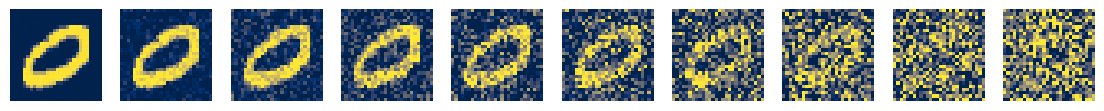

In [ ]:
#@title you may run this to make sure your implementation for q is good

x_0 = train_set[1][0].to(device)  # Initial image
plt.figure(figsize=(14, 8))

ddpm = DDPM(T=1000, img_shape=x_0.shape)

for t in range(0, ddpm.T, 100):
    t_tensor = torch.Tensor([t]).type(torch.int64)
    x_t, noise = ddpm.q(x_0, t_tensor)
    img = torch.squeeze(x_t).cpu()
    if t % 100 == 0:
      ax = plt.subplot(1, 10, t // 100 + 1)
      ax.axis('off')
      show_tensor_image(img)

![image.png](attachment:image.png)

## Train

In [ ]:
img_shape = train_set[0][0].shape
model = DDPM(T=1000, img_shape=img_shape)
print("Num params: {:,}".format(sum(p.numel() for p in model.parameters())))
model = torch.compile(model.to(device))

optimizer = optim.Adam(model.parameters(), lr=1e-3)
epochs = 20

Num params: 3,032,449


Epoch 1/20 [Train]:   0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/78 [00:00<?, ?it/s]

Epoch 01/20 | Train: 0.0489 | Val: 0.0481
New best model saved with Val Loss: 0.0481


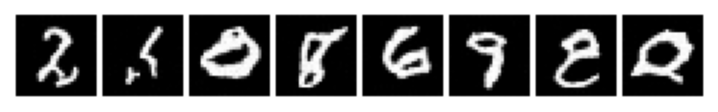

Epoch 2/20 [Train]:   0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/78 [00:00<?, ?it/s]

Epoch 02/20 | Train: 0.0481 | Val: 0.0486


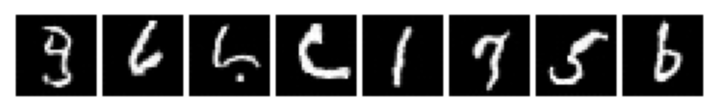

Epoch 3/20 [Train]:   0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/78 [00:00<?, ?it/s]

Epoch 03/20 | Train: 0.0470 | Val: 0.0459
New best model saved with Val Loss: 0.0459


Epoch 4/20 [Train]:   0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/78 [00:00<?, ?it/s]

Epoch 04/20 | Train: 0.0465 | Val: 0.0444
New best model saved with Val Loss: 0.0444


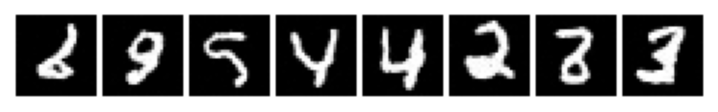

Epoch 5/20 [Train]:   0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/78 [00:00<?, ?it/s]

Epoch 05/20 | Train: 0.0463 | Val: 0.0460


Epoch 6/20 [Train]:   0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/78 [00:00<?, ?it/s]

Epoch 06/20 | Train: 0.0457 | Val: 0.0456


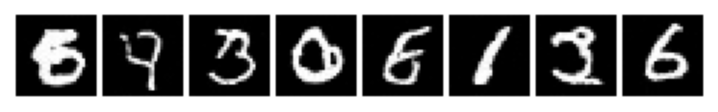

Epoch 7/20 [Train]:   0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/78 [00:00<?, ?it/s]

Epoch 07/20 | Train: 0.0451 | Val: 0.0450


Epoch 8/20 [Train]:   0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/78 [00:00<?, ?it/s]

Epoch 08/20 | Train: 0.0446 | Val: 0.0450


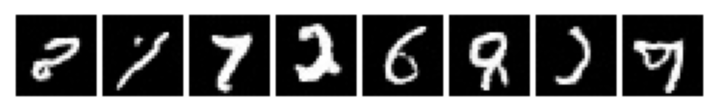

Epoch 9/20 [Train]:   0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/78 [00:00<?, ?it/s]

Epoch 09/20 | Train: 0.0443 | Val: 0.0441
New best model saved with Val Loss: 0.0441


Epoch 10/20 [Train]:   0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/78 [00:00<?, ?it/s]

Epoch 10/20 | Train: 0.0437 | Val: 0.0445


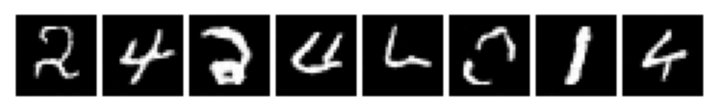

Epoch 11/20 [Train]:   0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/78 [00:00<?, ?it/s]

Epoch 11/20 | Train: 0.0433 | Val: 0.0428
New best model saved with Val Loss: 0.0428


Epoch 12/20 [Train]:   0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/78 [00:00<?, ?it/s]

Epoch 12/20 | Train: 0.0431 | Val: 0.0436


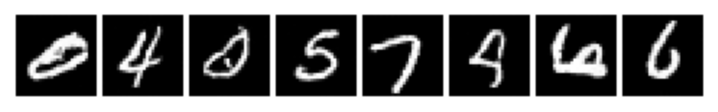

Epoch 13/20 [Train]:   0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/78 [00:00<?, ?it/s]

Epoch 13/20 | Train: 0.0431 | Val: 0.0433


Epoch 14/20 [Train]:   0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/78 [00:00<?, ?it/s]

Epoch 14/20 | Train: 0.0432 | Val: 0.0426
New best model saved with Val Loss: 0.0426


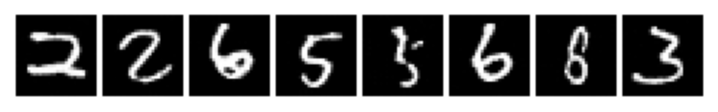

Epoch 15/20 [Train]:   0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/78 [00:00<?, ?it/s]

Epoch 15/20 | Train: 0.0423 | Val: 0.0426
New best model saved with Val Loss: 0.0426


Epoch 16/20 [Train]:   0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/78 [00:00<?, ?it/s]

Epoch 16/20 | Train: 0.0422 | Val: 0.0416
New best model saved with Val Loss: 0.0416


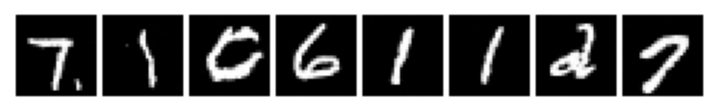

Epoch 17/20 [Train]:   0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/78 [00:00<?, ?it/s]

Epoch 17/20 | Train: 0.0420 | Val: 0.0420


Epoch 18/20 [Train]:   0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/78 [00:00<?, ?it/s]

Epoch 18/20 | Train: 0.0425 | Val: 0.0425


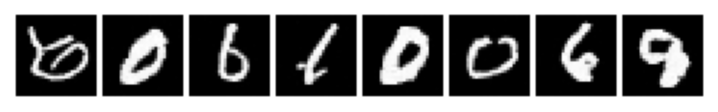

Epoch 19/20 [Train]:   0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/78 [00:00<?, ?it/s]

Epoch 19/20 | Train: 0.0419 | Val: 0.0419


Epoch 20/20 [Train]:   0%|          | 0/390 [00:00<?, ?it/s]

  0%|          | 0/78 [00:00<?, ?it/s]

Epoch 20/20 | Train: 0.0417 | Val: 0.0413
New best model saved with Val Loss: 0.0413


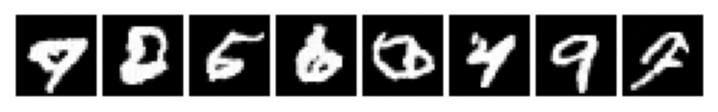

In [ ]:
epoch_train_losses = []
epoch_val_losses = []

# Initialize the best validation loss to infinity
best_val_loss = float('inf')

for epoch in range(epochs):
    model.train()
    batch_losses = []

    # 1. Training Phase
    for imgs, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
        imgs = imgs.to(device)
        optimizer.zero_grad()
        loss = model.training_step(imgs)
        loss.backward()
        optimizer.step()

        batch_losses.append(loss.item())

    avg_train_loss = sum(batch_losses) / len(batch_losses)
    epoch_train_losses.append(avg_train_loss)

    # 2. Validation Phase
    val_loss = model.validation_step(val_loader)
    epoch_val_losses.append(val_loss)

    print(f"Epoch {epoch+1:02d}/{epochs} | Train: {avg_train_loss:.4f} | Val: {val_loss:.4f}")

    # Checkpoint the best model ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_mnist_ddpm.pth')
        print(f"New best model saved with Val Loss: {best_val_loss:.4f}")

    # 3. Observation Phase (Plotting every 2 epochs)
    if (epoch + 1) % 2 == 0 or epoch == 0:
        with torch.no_grad():
            sampled_sequence = model.sample(num_imgs=8, skip=999)
            final_images = sampled_sequence[-1].cpu()
            show_imgs(final_images)

### Training Curve


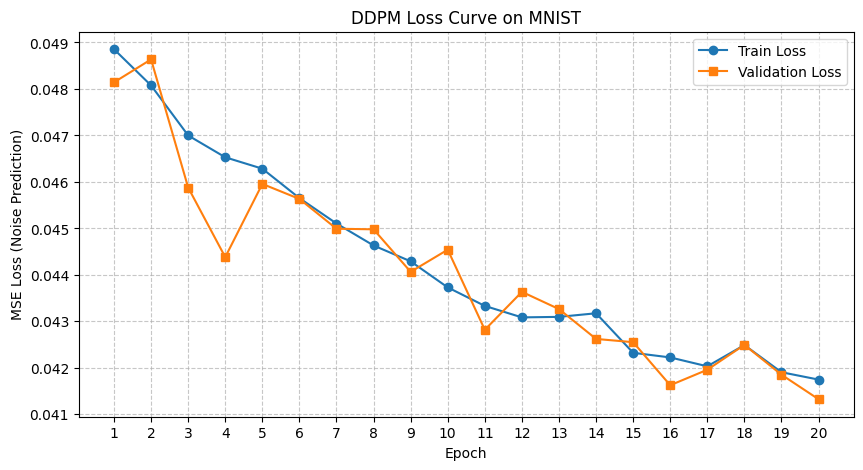

In [ ]:
# Plotting the Training and Validation Loss Curves
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), epoch_train_losses, label='Train Loss', marker='o')
plt.plot(range(1, epochs + 1), epoch_val_losses, label='Validation Loss', marker='s')
plt.title('DDPM Loss Curve on MNIST')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss (Noise Prediction)')
plt.xticks(range(1, epochs + 1))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Samples


Samples generated from the Gaussian prior:


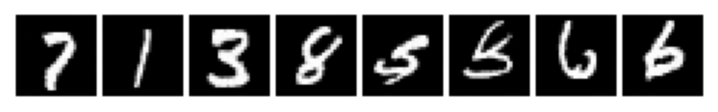

In [ ]:
model.eval()

print('Samples generated from the Gaussian prior:')
with torch.no_grad():

    sequence = model.sample(num_imgs=8)

    generated = sequence[-1].cpu()

show_imgs(generated)

![image.png](attachment:image.png)
![image-2.png](attachment:image-2.png)

## Autocomplete two images

In [ ]:
def complete_image(model, y, ymask, scale=10.0):
    """
    Conditionally generates the missing parts of an image.
    """
    model.eval()
    device = next(model.parameters()).device
    num_imgs = y.size(0)

    # Start from pure noise
    x_t = torch.randn_like(y).to(device)

    for i in tqdm(reversed(range(model.T)), total=model.T, desc="Inpainting", leave=False):
        t = torch.full((num_imgs,), i, device=device, dtype=torch.long)

        # 1. We need gradients to flow strictly through the input tensor
        x_t_var = x_t.detach().requires_grad_(True)

        with torch.enable_grad():
            # 2. Backpropagate through the UNet (Lecturer's Option 1)
            # This ensures the gradient respects the structural manifold of a digit
            e_t = model.net(x_t_var, t)

            # Predict x0
            x0_hat = model.get_x0_pred(x_t_var, t, e_t)

            # 3. Calculate MSE using MEAN reduction to prevent gradient explosion!
            loss = F.mse_loss(ymask * x0_hat, ymask * y, reduction='mean')

            # Calculate the gradient of the loss with respect to x_t
            grad = torch.autograd.grad(loss, x_t_var)[0]

        # 4. Take the standard reverse step using the detached noise
        with torch.no_grad():
            x_t_minus_1 = model.reverse_q(x_t_var, t, e_t.detach())

            # Add the scaled correction term
            x_t = x_t_minus_1 - scale * grad

    return x_t

In [ ]:
# 1. Create the fixed architecture
model = DDPM(T=1000, img_shape=(1, 28, 28)).to(device)

# 2. Load the raw dictionary from the file
state_dict = torch.load('best_mnist_ddpm.pth', weights_only=True)

# 3. Strip the '_orig_mod.' prefix from all keys
clean_state_dict = {}
for key, value in state_dict.items():
    if key.startswith('_orig_mod.'):
        # Remove the first 10 characters ('_orig_mod.')
        clean_key = key[10:]
        clean_state_dict[clean_key] = value
    else:
        clean_state_dict[key] = value

# 4. Load the cleaned dictionary into the model
model.load_state_dict(clean_state_dict)
model.eval()

print("Prefixes stripped and weights restored! Ready to generate.")

Prefixes stripped and weights restored! Ready to generate.


Generating conditional samples...


Inpainting:   0%|          | 0/1000 [00:00<?, ?it/s]

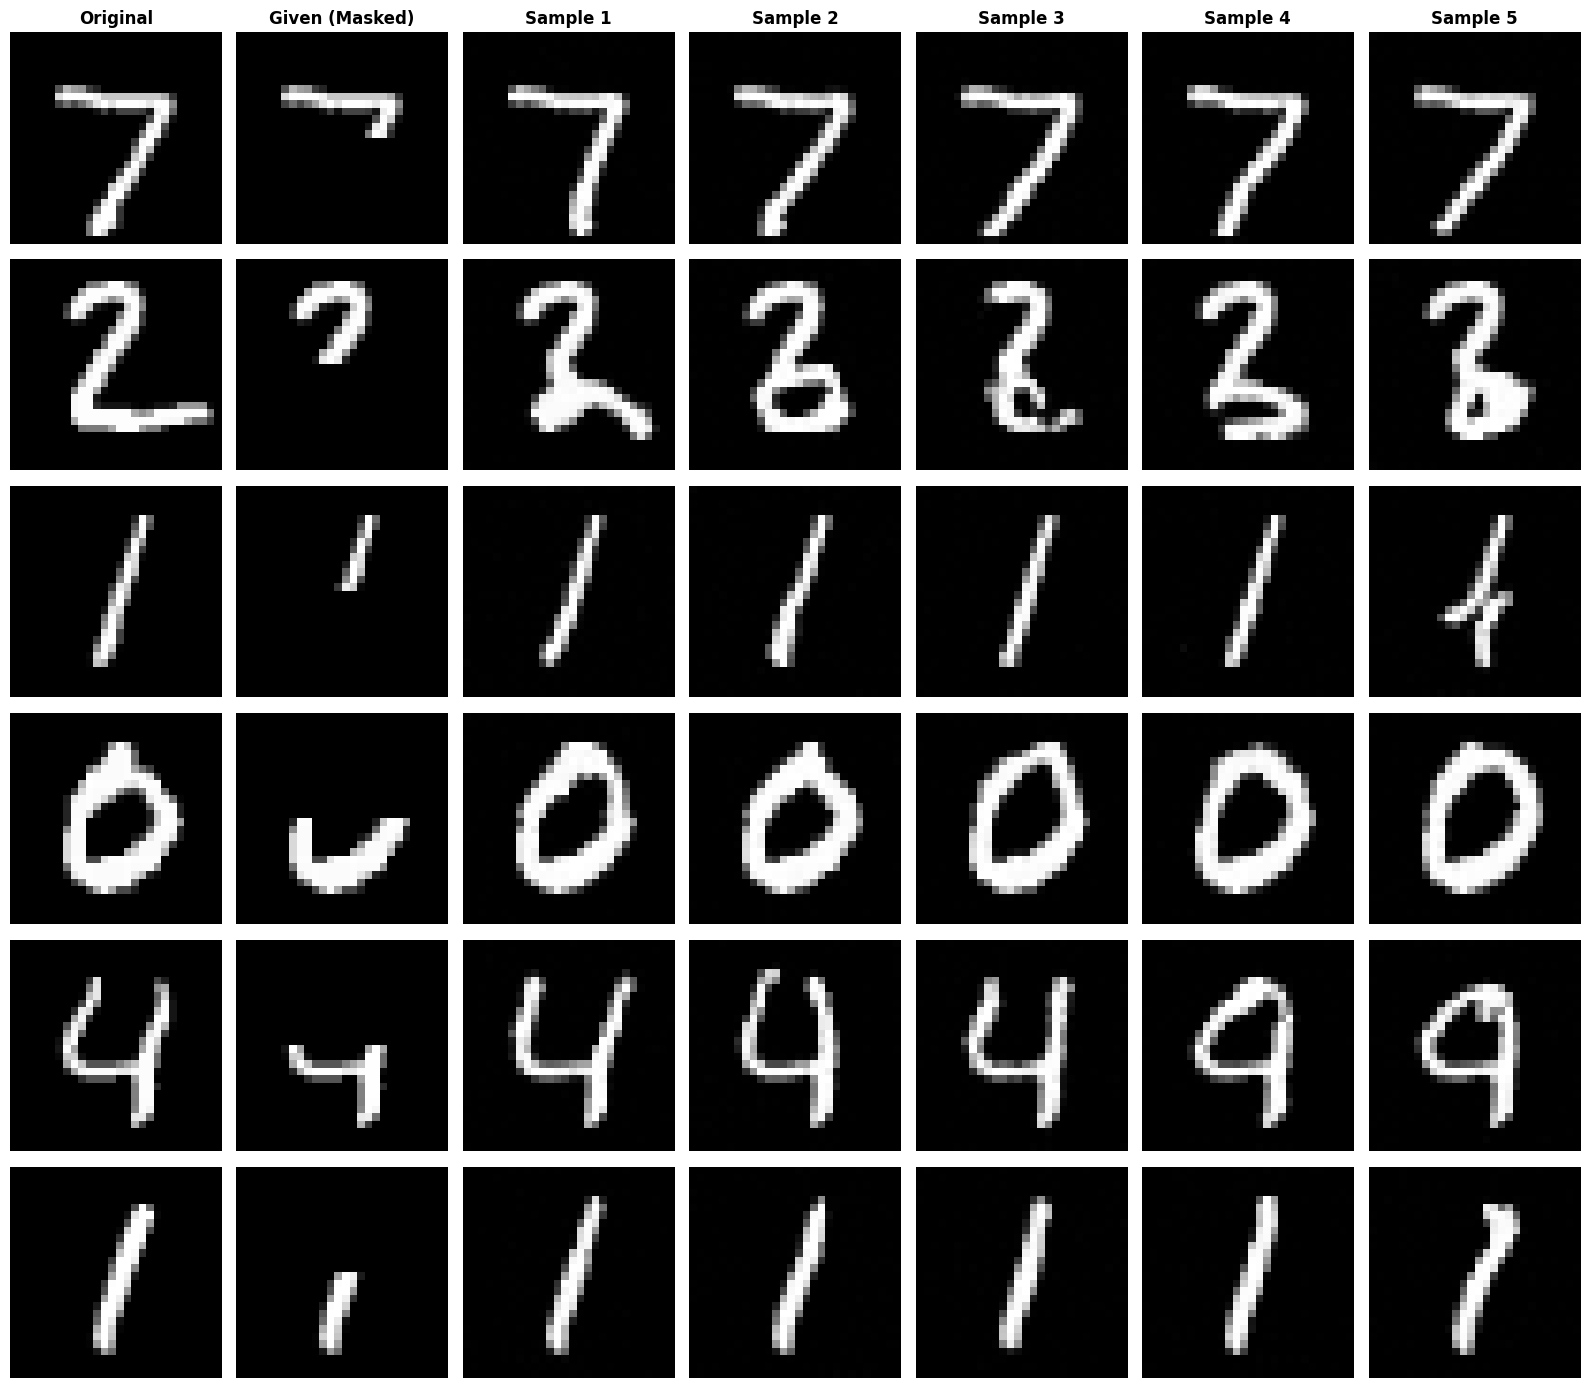

In [ ]:
# 1. Get 6 real images from the test set
imgs, _ = next(iter(test_loader))
imgs = imgs[:6].to(device)

# 2. Create the masks
_, _, H, W = imgs.shape
masks = torch.ones_like(imgs)

# Hide the bottom half for the first 3 images (Set bottom rows to 0)
masks[:3, :, H//2:, :] = 0.0

# Hide the top half for the second 3 images (Set top rows to 0)
masks[3:, :, :H//2, :] = 0.0

# Apply the masks to create 'y'
y = imgs * masks

# 3. Prepare for batch generation
num_samples = 5
# Repeat each image and mask 5 times so we can generate them all in one fast batch
# Shape goes from (6, C, H, W) -> (30, C, H, W)
y_repeated = y.repeat_interleave(num_samples, dim=0)
masks_repeated = masks.repeat_interleave(num_samples, dim=0)

# 4. Perform Probabilistic Inference
print("Generating conditional samples...")
with torch.no_grad():
    completed_batch = complete_image(model, y_repeated, masks_repeated, scale=100.0)

    # Un-normalize from [-1, 1] back to [0, 1] for visualization
    completed_batch = (completed_batch + 1.0) / 2.0
    completed_batch = completed_batch.clamp(0.0, 1.0)

    y_plot = (y + 1.0) / 2.0
    imgs_plot = (imgs + 1.0) / 2.0

# Reshape the output back to (6_images, 5_samples, C, H, W) for easy plotting
completed_samples = completed_batch.view(6, num_samples, 1, H, W)

# 5. Plotting the Grid
fig, axes = plt.subplots(6, 7, figsize=(16, 14))

for i in range(6):
    # Column 1: Original Image
    ax = axes[i, 0]
    ax.imshow(imgs_plot[i, 0].cpu(), cmap='gray')
    ax.axis('off')
    if i == 0: ax.set_title("Original", fontweight='bold')

    # Column 2: Masked Image (y)
    ax = axes[i, 1]
    # For visualization, let's make the masked out part actually look black
    # instead of gray from the normalization
    masked_vis = imgs_plot[i, 0].cpu() * masks[i, 0].cpu()
    ax.imshow(masked_vis, cmap='gray')
    ax.axis('off')
    if i == 0: ax.set_title("Given (Masked)", fontweight='bold')

    # Columns 3-7: The 5 generated samples
    for j in range(num_samples):
        ax = axes[i, 2 + j]
        ax.imshow(completed_samples[i, j, 0].cpu(), cmap='gray')
        ax.axis('off')
        if i == 0: ax.set_title(f"Sample {j+1}", fontweight='bold')

plt.tight_layout()
plt.show()

## CelebA - Adding context

MNIST is boring! Moreover, what is the point of generating samples without controling them? <br/>
We will use a pretrained CLIP (Contrastive Language-Image Pre-Training).

CLIP creates embeddings of both text and images such that images are aligned to the text that describes them. We will use this to encode text and decode into a new image.

In [2]:
!pip install --quiet git+https://github.com/openai/CLIP.git

import glob
import csv
from textwrap import wrap

import clip

from PIL import Image
import numpy as np

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.9 MB/s eta 0:00:00


## Load data
Go to your <a href="https://www.kaggle.com/">Kaggle</a> account and under the settings, generate new API token. <br/>
This will export you a json file, which you will upload here.

In [3]:
# The script expects you to upload JSON file to it!

! pip install -q kaggle
from google.colab import files
files.upload()
! mkdir ~/.kaggle
! cp kaggle.json ~/.kaggle/
! chmod 600 ~/.kaggle/kaggle.json
! kaggle datasets list
! kaggle datasets download jessicali9530/celeba-dataset
! unzip -q celeba-dataset.zip -d faces

Saving kaggle.json to kaggle.json
ref                                                             title                                                    size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  -------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
rauffauzanrambe/fifa-world-cup-2026-player-performance-dataset  FIFA World Cup 2026 Player Performance Dataset        4154062  2026-06-10 12:58:47.093000           9934        241                1  
ashyou09/apple-products-pricing-dataset-2020-2026               Apple Products Pricing Dataset (2020-2026)🍎           1569012  2026-07-04 16:06:56.590000           1138         20                1  
arjunmehta1992/chocolate-sales-in-20222023                      Chocolate Sales in 2022–2023                          4820417  2026-06-21 03:52:16.600000           3469  

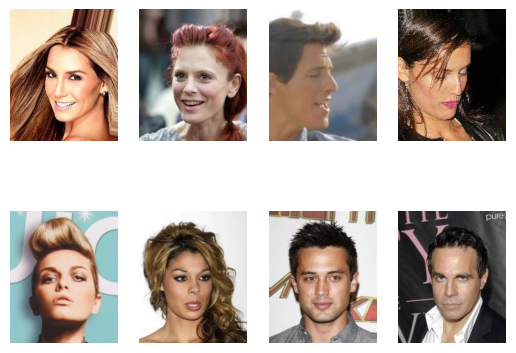

In [8]:
FACES_PATH = "/content/faces/img_align_celeba/img_align_celeba"

for i in range(1,9):
  img = Image.open(f'{FACES_PATH}/00000{i}.jpg')
  plt.subplot(2, 4, i)
  plt.axis('off')
  plt.imshow(img)

plt.show()

## load pretrained model

In [9]:
clip.available_models()

['RN50',
 'RN101',
 'RN50x4',
 'RN50x16',
 'RN50x64',
 'ViT-B/32',
 'ViT-B/16',
 'ViT-L/14',
 'ViT-L/14@336px']

In [10]:
clip_model, clip_preprocess = clip.load("ViT-B/32")
clip_model.eval()
CLIP_FEATURES = 512

100%|████████████████████████████████████████| 338M/338M [00:02<00:00, 151MiB/s]


## Intro to CLIP

Load image using CLIP

In [11]:
img = Image.open(f'{FACES_PATH}/000001.jpg')

clip_imgs = torch.tensor(np.stack([clip_preprocess(img)])).to(device)
print("After image clip preprocessing the size is ", clip_imgs.size())

After image clip preprocessing the size is  torch.Size([1, 3, 224, 224])


Feature extractor of CLIP

In [12]:
clip_img_encoding = clip_model.encode_image(clip_imgs)
print(clip_img_encoding.size())

torch.Size([1, 512])


Now, we want to see how to tokenize text and encoder it using clip

In [13]:
text_list = [
    "An Angry man",
    "Smiling bald person",
    "Happy beautiful woman"
]
text_tokens = clip.tokenize(text_list).to(device)
print("Text tokens")
print(text_tokens[:,:10])
print("----------------------------")

clip_text_encodings = clip_model.encode_text(text_tokens).float()
print("For each text, encoding of 512 features ", clip_text_encodings.size())
print(clip_text_encodings)

Text tokens
tensor([[49406,   550,  9054,   786, 49407,     0,     0,     0,     0,     0],
        [49406,  9200, 14875,  2533, 49407,     0,     0,     0,     0,     0],
        [49406,   900,  1215,  2308, 49407,     0,     0,     0,     0,     0]],
       device='cuda:0', dtype=torch.int32)
----------------------------
For each text, encoding of 512 features  torch.Size([3, 512])
tensor([[-0.1211,  0.0484,  0.1675,  ..., -0.4663,  0.4883, -0.2671],
        [-0.0769,  0.0007, -0.1137,  ..., -0.1329,  0.0972,  0.0560],
        [ 0.2595,  0.0418, -0.0429,  ..., -0.4988, -0.2382, -0.0294]],
       device='cuda:0', grad_fn=<ToCopyBackward0>)


In order to see which one of our text descriptions best describes the faces, we can calculate the cosine similarity between the text encodings and the image encodings. <br/>
We will load three flowers, give each its encoding and will compare to the texts above

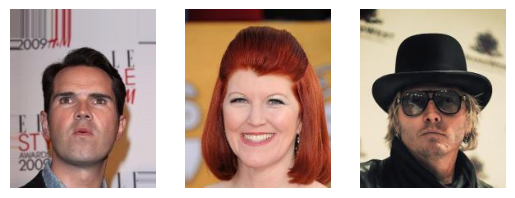

In [14]:
def get_img_encodings(imgs):
    processed_imgs = [clip_preprocess(img) for img in imgs]
    clip_imgs = torch.tensor(np.stack(processed_imgs)).to(device)
    clip_img_encodings = clip_model.encode_image(clip_imgs)
    return clip_img_encodings

imgs = [Image.open(f"{FACES_PATH}/{i}.jpg") for i in ["000069", "000174", "000154"]]
for i, img in enumerate(imgs):
    plt.subplot(1,3,i+1)
    plt.axis('off')
    plt.imshow(img)

In [15]:
clip_img_encodings = get_img_encodings(imgs)    # torch.Tensor([3, 512])

text_list = [
    "A surprised man with black hair",
    "A woman smiling with red hair",
    "A person with black glasses and wears black hat"
]

text_tokens = clip.tokenize(text_list).to(device)
clip_text_encodings = clip_model.encode_text(text_tokens)   # torch.Tensor([3, 512])

clip_img_encodings /= clip_img_encodings.norm(dim=-1, keepdim=True)
clip_text_encodings /= clip_text_encodings.norm(dim=-1, keepdim=True)

similarity = clip_img_encodings @ clip_text_encodings.T

print(similarity)

tensor([[0.2708, 0.1172, 0.2247],
        [0.1606, 0.3018, 0.2135],
        [0.1760, 0.0996, 0.3140]], device='cuda:0', dtype=torch.float16,
       grad_fn=<MmBackward0>)


Well, is there a match?

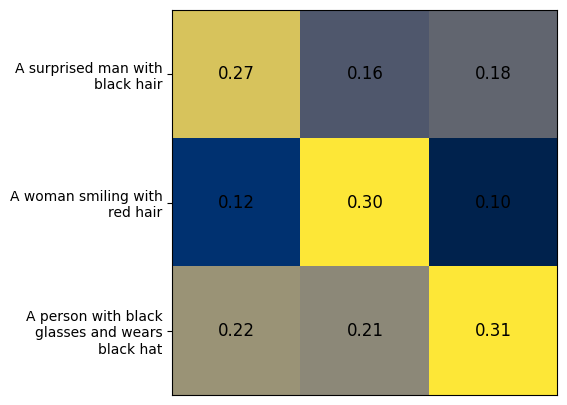

In [16]:
fig = plt.figure(figsize=(10, 10))
gs = fig.add_gridspec(2, 3, wspace=.1, hspace=0)

ax = fig.add_subplot(gs[1, :])
plt.imshow(similarity.detach().cpu().numpy().T, vmin=0.1, vmax=0.3)

labels = [ '\n'.join(wrap(text, 20)) for text in text_list ]
plt.yticks(range(len(text_tokens)), labels, fontsize=10)
plt.xticks([])

for x in range(similarity.shape[1]):
    for y in range(similarity.shape[0]):
        plt.text(x, y, f"{similarity[x, y]:.2f}", ha="center", va="center", size=12)

Collabory: CLIP gives the most similar encoding of image to the most similar encoding of text.
Hence, we will train using the image encoding, but create new images using an encoding of text, hopefully it will work

## Proccess the data using clip

In [17]:
CLIP_FEATURES = 512

def crop_face(sample):
  return sample[:, 9:(9+32),4:(4+32)]

pre_transforms = transforms.Compose([
    transforms.Resize((50, 40)),
    transforms.ToTensor(),  # Scales data into [0,1]
    crop_face,
    transforms.Lambda(lambda t: (t * 2) - 1)  # Scale between [-1, 1]
])

random_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
])

With our current resources, we DO NOT want to encode ~50000 images. Download the csv file. It contains the file paths, along with its preprocessed CLIP data.

Remark: the file contains 202k images. Training on all of them is an excellent idea - example will be attached at the end

In [18]:
!wget https://srworkspace.com/sharon/dgm/clip_data.zip
!unzip -q clip_data.zip

--2026-07-09 12:49:47--  https://srworkspace.com/sharon/dgm/clip_data.zip
Resolving srworkspace.com (srworkspace.com)... 93.127.136.181
Connecting to srworkspace.com (srworkspace.com)|93.127.136.181|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 344697039 (329M) [application/zip]
Saving to: ‘clip_data.zip’

clip_data.zip       100%[===================>] 328.73M  1.13MB/s    in 69s     

2026-07-09 12:50:56 (4.79 MB/s) - ‘clip_data.zip’ saved [344697039/344697039]



In [19]:
import glob
import csv
from torch.utils.data import Dataset

class MyDataset(Dataset):
    def __init__(self, csv_path='clip_data.csv', max_samples=50_000):
        self.imgs = []
        self.labels = torch.empty(
            max_samples, CLIP_FEATURES, dtype=torch.float, device=device
        )

        with open(csv_path, newline='') as csvfile:
            reader = csv.reader(csvfile, delimiter=',')
            for idx, row in tqdm(enumerate(reader), total=max_samples):
                if idx >= max_samples:
                    break
                img = Image.open(row[0])
                self.imgs.append(pre_transforms(img).to(device))
                label = [float(x) for x in row[1:]]
                self.labels[idx, :] = torch.FloatTensor(label).to(device)

    def __getitem__(self, idx):
        return random_transforms(self.imgs[idx]), self.labels[idx]

    def __len__(self):
        return len(self.imgs)

data_paths = glob.glob(f'{FACES_PATH}/*.jpg', recursive=True)
faces_data = MyDataset()
faces_dataloader = data.DataLoader(faces_data, batch_size=128, shuffle=True, drop_last=True)

  0%|          | 0/50000 [00:00<?, ?it/s]

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [21]:
#@title Components of UNet
import math

class GELUConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, group_size):
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, 3, 1, 1),
            nn.GroupNorm(group_size, out_ch),
            nn.GELU(),
        ]
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


class RearrangePoolBlock(nn.Module):
    def __init__(self, in_chs, group_size):
        super().__init__()
        self.rearrange = nn.MaxPool2d(2)
        self.conv = GELUConvBlock(in_chs, in_chs, group_size)

    def forward(self, x):
        x = self.rearrange(x)
        return self.conv(x)


class DownBlock(nn.Module):
    def __init__(self, in_chs, out_chs, group_size):
        super(DownBlock, self).__init__()
        layers = [
            GELUConvBlock(in_chs, out_chs, group_size),
            GELUConvBlock(out_chs, out_chs, group_size),
            RearrangePoolBlock(out_chs, group_size),
        ]
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


class UpBlock(nn.Module):
    def __init__(self, in_chs, out_chs, group_size):
        super(UpBlock, self).__init__()
        layers = [
            nn.ConvTranspose2d(2 * in_chs, out_chs, 2, 2),
            GELUConvBlock(out_chs, out_chs, group_size),
            GELUConvBlock(out_chs, out_chs, group_size),
            GELUConvBlock(out_chs, out_chs, group_size),
            GELUConvBlock(out_chs, out_chs, group_size),
        ]
        self.model = nn.Sequential(*layers)

    def forward(self, x, skip):
        x = torch.cat((x, skip), 1)
        x = self.model(x)
        return x


class SinusoidalPositionEmbedBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings


class EmbedBlock(nn.Module):
    def __init__(self, input_dim, emb_dim):
        super(EmbedBlock, self).__init__()
        self.input_dim = input_dim
        layers = [
            nn.Linear(input_dim, emb_dim),
            nn.GELU(),
            nn.Linear(emb_dim, emb_dim),
            nn.Unflatten(1, (emb_dim, 1, 1)),
        ]
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        x = x.view(-1, self.input_dim)
        return self.model(x)


class ResidualConvBlock(nn.Module):
    def __init__(self, in_chs, out_chs, group_size):
        super().__init__()
        self.conv1 = GELUConvBlock(in_chs, out_chs, group_size)
        self.conv2 = GELUConvBlock(out_chs, out_chs, group_size)

    def forward(self, x):
        x1 = self.conv1(x)
        x2 = self.conv2(x1)
        out = x1 + x2
        return out

## Recap on guidance

So far, the models have generated image without control, but if we somehow embed what we want into the model, it will be taken into account during training!

We use CLIP to encode text into embedding. Then, we will **not** feed it directly to the model, but rather apply a "dropout" on it first, as it will maintain divergence and prevent overfitting (see ```get_context_mask``` later).

Then, at sampling, when removing noise, we will predict two types of noise:
- "keep context" (uses context mask with $p=0$)
- "remove context" (uses context mask with $p=1$)

As always, there is tradeoff, weigted over both noises using
$$
\epsilon_t=\epsilon_θ(x_t,c=1) \cdot (1+s)-\epsilon_θ(x_t,c=0) \cdot s
$$

Here is an example for impact of $s$, when we ignore the $\text{keep}\times 1$:

<img width="50%" src="https://srworkspace.com/sharon/dgm/guidance.png"/>


## Modify the model

<img width="70%" src="https://sharon.srworkspace.com/dgm/context1.png"/>

In [22]:
class UNet(nn.Module):
    def __init__(self, T, img_shape):
        super(UNet, self).__init__()
        img_chs = img_shape[0]
        self.T = T
        down_chs = (32, 64, 128)
        up_chs = down_chs[::-1]  # Reverse of the down channels
        latent_image_size = img_shape[1] // 4 # 2 ** (len(down_chs) - 1)
        t_embed_dim = 16
        c_embed_dim=CLIP_FEATURES # New

        small_group_size = 8 # New
        big_group_size = 32 # New

        # Inital convolution
        self.down0 = ResidualConvBlock(img_chs, down_chs[0], small_group_size)

        # Downsample
        self.down1 = DownBlock(down_chs[0], down_chs[1], big_group_size)
        self.down2 = DownBlock(down_chs[1], down_chs[2], big_group_size)
        self.to_vec = nn.Sequential(nn.Flatten(), nn.GELU())

        # Embeddings
        self.dense_emb = nn.Sequential(
            nn.Linear(down_chs[2] * latent_image_size**2, down_chs[1]),
            nn.ReLU(),
            nn.Linear(down_chs[1], down_chs[1]),
            nn.ReLU(),
            nn.Linear(down_chs[1], down_chs[2] * latent_image_size**2),
            nn.ReLU(),
        )
        self.sinusoidaltime = SinusoidalPositionEmbedBlock(t_embed_dim)
        self.temb_1 = EmbedBlock(t_embed_dim, up_chs[0])
        self.temb_2 = EmbedBlock(t_embed_dim, up_chs[1])
        self.c_embed1 = EmbedBlock(c_embed_dim, up_chs[0])
        self.c_embed2 = EmbedBlock(c_embed_dim, up_chs[1])

        # Upsample
        self.up0 = nn.Sequential(
            nn.Unflatten(1, (up_chs[0], latent_image_size, latent_image_size)),
            GELUConvBlock(up_chs[0], up_chs[0], big_group_size),
        )
        self.up1 = UpBlock(up_chs[0], up_chs[1], big_group_size)
        self.up2 = UpBlock(up_chs[1], up_chs[2], big_group_size)

        # Match output channels and one last concatenation
        self.out = nn.Sequential(
            nn.Conv2d(2 * up_chs[-1], up_chs[-1], 3, 1, 1),
            nn.GroupNorm(small_group_size, up_chs[-1]),
            nn.ReLU(),
            nn.Conv2d(up_chs[-1], img_chs, 3, 1, 1),
        )

    def forward(self, x, t, c, c_mask=None):
        # 1. Apply Classifier-Free Guidance Mask to the text embeddings
        # If c_mask is provided, it zeroes out the text context for unconditional learning
        if c_mask is not None:
            c = c * c_mask

        # 2. Time Processing (Convert integer t to float [0, 1] as required)
        t = t.float() / self.T
        t_emb = self.sinusoidaltime(t)

        # 3. Generate Layer-Specific Embeddings
        # We use .view() to reshape the 2D embeddings into 4D spatial tensors (Batch, Channels, 1, 1)
        # so they can be broadcasted across the height and width of the image feature maps.
        t1 = self.temb_1(t_emb).view(x.shape[0], -1, 1, 1) # 128 channels
        t2 = self.temb_2(t_emb).view(x.shape[0], -1, 1, 1) # 64 channels

        c1 = self.c_embed1(c).view(x.shape[0], -1, 1, 1)   # 128 channels
        c2 = self.c_embed2(c).view(x.shape[0], -1, 1, 1)   # 64 channels

        # 4. Downsampling Path
        d0 = self.down0(x)       # Output: 32 channels
        d1 = self.down1(d0)      # Output: 64 channels
        d2 = self.down2(d1)      # Output: 128 channels

        # 5. Latent Bottleneck
        vec = self.to_vec(d2)
        emb = self.dense_emb(vec)

        # 6. Upsampling Path with Skip Connections & Condition Injections
        u0 = self.up0(emb)       # Output: 128 channels

        # Inject the first set of time and text embeddings
        u0 = u0 + t1 + c1

        # Concatenate u0 with d2 (inside up1) -> Output: 64 channels
        u1 = self.up1(u0, d2)

        # Inject the second set of time and text embeddings
        u1 = u1 + t2 + c2

        # Concatenate u1 with d1 (inside up2) -> Output: 32 channels
        u2 = self.up2(u1, d1)

        # 7. Final Output Projection
        # Concatenate u2 (32 channels) and d0 (32 channels) to make the 64 channels expected by self.out
        out_input = torch.cat((u2, d0), dim=1)
        out = self.out(out_input)

        return out

In [23]:
class DDPM(nn.Module):
    def __init__(self, T, img_shape, method='cosine'):
        super(DDPM, self).__init__()
        self.T = T

        epsilon=0.008
        if method == 'cosine':
            steps=torch.linspace(0,T,steps=T+1).to(device)
            f_t=torch.cos(((steps/T+epsilon)/(1.0+epsilon))*math.pi*0.5)**2
            self.Beta = torch.clip(1.0-f_t[1:]/f_t[:T], 0.0, 0.999)

        elif method == 'linear':
            self.Beta = torch.linspace(1e-4, 2e-2, T).to(device)

        # Forward diffusion variables
        self.a = 1.0 - self.Beta
        self.a_bar = torch.cumprod(self.a, dim=0)

        self.img_chs = img_shape[0]
        self.img_size = img_shape[1]

        self.net = UNet(T, img_shape)

        # Logging
        self.logs = defaultdict(list)

    def log(self, key, value):
        self.logs[key].append(value)

    def q(self, x_0, t):
        """
        Samples a new image from q
        Returns a tuple (img_after_noise, noise) at timestep t
        """
        noise = torch.randn_like(x_0)
        a_bar_t = self.a_bar[t].view(-1, 1, 1, 1)

        # Standard forward diffusion
        x_t = torch.sqrt(a_bar_t) * x_0 + torch.sqrt(1.0 - a_bar_t) * noise
        return x_t, noise

    @torch.no_grad()
    def reverse_q(self, x_t, t, e_t):
        """
        Computes the reverse diffusion step q(x_{t-1} | x_t, e_t)
        """
        a_t = self.a[t].view(-1, 1, 1, 1)
        a_bar_t = self.a_bar[t].view(-1, 1, 1, 1)
        beta_t = self.Beta[t].view(-1, 1, 1, 1)

        # Calculate the predicted mean using the noise e_t
        mean = (1.0 / torch.sqrt(a_t)) * (x_t - ((1.0 - a_t) / torch.sqrt(1.0 - a_bar_t)) * e_t)

        mask = (t > 0).float().view(-1, 1, 1, 1)
        z = torch.randn_like(x_t)

        x_t_minus_1 = mean + mask * torch.sqrt(beta_t) * z
        return x_t_minus_1

    def get_context_mask(self, c, drop_prob=0.1):
        c_mask = torch.bernoulli(torch.ones_like(c).float() - drop_prob).to(device)
        return c_mask

    def get_loss(self, x_0, t, c):
        """
        Returns the loss between the true noise and the predicted noise
        x_0: the original image
        t: timestep
        c: clip embeddings
        """
        # 1. Forward diffuse the image
        x_t, true_noise = self.q(x_0, t)

        # 2. Apply Classifier-Free Guidance dropout
        # We randomly drop out the text embedding (e.g., 10% of the time)
        # by multiplying it by 0. This forces the UNet to also learn how
        # to generate images unconditionally.
        c_mask = self.get_context_mask(c, drop_prob=0.1)
        c_masked = c * c_mask

        # 3. Predict noise using the image, time, and masked text context
        pred_noise = self.net(x_t, t, c_masked)

        # 4. Return MSE
        loss = F.mse_loss(pred_noise, true_noise)
        return loss


    @torch.no_grad()
    def sample(self, text_list, s=0.5):
        self.eval()
        device = next(self.parameters()).device

        # In this context, text_list is acting as the CLIP embedding tensor 'c'.
        c = text_list
        num_imgs = len(c)

        # Noise to generate images from
        x_t = torch.randn(num_imgs, self.img_chs, self.img_size, self.img_size).to(device)

        # Create a "null" context tensor of all zeros for unconditional generation
        uncond_c = torch.zeros_like(c).to(device)

        # Iterate backward from T-1 down to 0
        for i in tqdm(reversed(range(self.T)), total=self.T, desc="Sampling (CFG)", leave=False):
            t = torch.full((num_imgs,), i, device=device, dtype=torch.long)

            # 1. Predict noise with the text condition (What the text wants)
            e_cond = self.net(x_t, t, c)

            # 2. Predict noise without the text condition (What the baseline model wants)
            e_uncond = self.net(x_t, t, uncond_c)

            # 3. Classifier-Free Guidance extrapolation
            # We push the prediction away from the unconditional baseline and towards the conditioned prompt.
            # 's' controls how strongly we follow the text prompt.
            e_t = (1.0 + s) * e_cond - s * e_uncond

            # 4. Take the standard reverse step using the guided noise
            x_t = self.reverse_q(x_t, t, e_t)

        return x_t      # (|text_list|, img_chs, IMG_SIZE, IMG_SIZE)

    def log(self, key, value):
        self.logs[key].append(value)

    def training_step(self, imgs, clip_desc):
        t = torch.randint(0, self.T, (len(imgs),), device=device)
        loss = self.get_loss(imgs, t, clip_desc)

        # Log losses
        self.log('train_loss', loss.item())
        return loss

## Train

This text list will be sampled at the end of each epoch, but does not affect the training.

In [24]:
# Change me
text_list = [
    "A man wearing a white hat",
    "A woman in sun glasses",
    "A man with green hair and a blue shirt",
    "A sad woman with blue eyes"
]

In [25]:
img_shape = faces_data[0][0].shape
model = DDPM(T=300, img_shape=img_shape, method='linear')
print("Num params: {:,}".format(sum(p.numel() for p in model.parameters())))
model = torch.compile(model.to(device))

optimizer = optim.Adam(model.parameters(), lr=1e-3)
epochs = 50

Num params: 2,111,619


  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 0 | Loss: 0.05480792604577847 


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

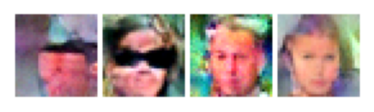

  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 1 | Loss: 0.053626340971543236 


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

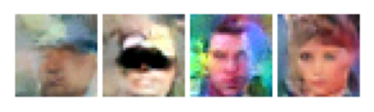

  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 2 | Loss: 0.053271927684545514 


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

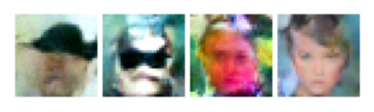

  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 3 | Loss: 0.05243368101043579 


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

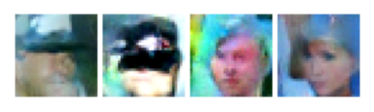

  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 4 | Loss: 0.051878499917877026 


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

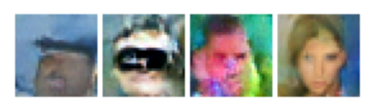

  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 5 | Loss: 0.05079127224401021 


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

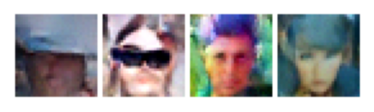

  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 6 | Loss: 0.05067588590467587 


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

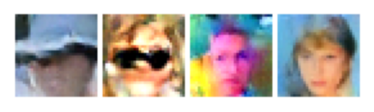

  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 7 | Loss: 0.05077820621812955 


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

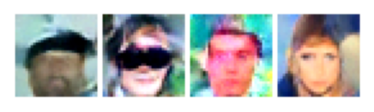

  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 8 | Loss: 0.05023577246719446 


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

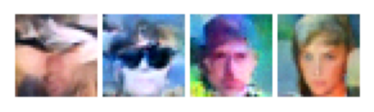

  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 9 | Loss: 0.04979108316011918 


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

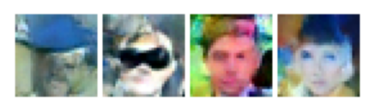

  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 10 | Loss: 0.0498765352444771 


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

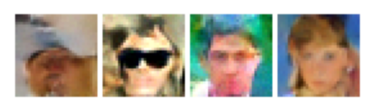

  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 11 | Loss: 0.04929987047918332 


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

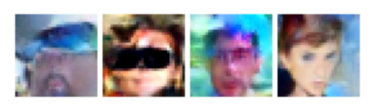

  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 12 | Loss: 0.04914862653001761 


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

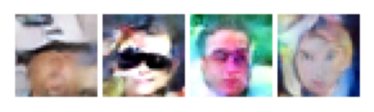

  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 13 | Loss: 0.04903102100659639 


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

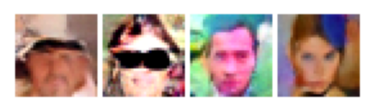

  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 14 | Loss: 0.04930332645009725 


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

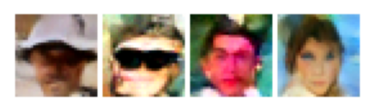

  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 15 | Loss: 0.04890929282857821 


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

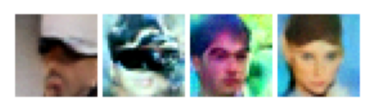

  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 16 | Loss: 0.04904441349685956 


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

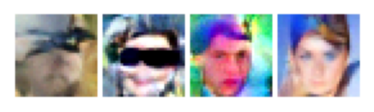

  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 17 | Loss: 0.04907751318353873 


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

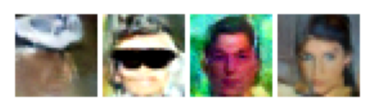

  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 18 | Loss: 0.04897956404452904 


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

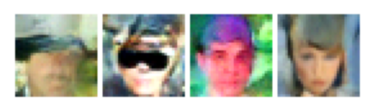

  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 19 | Loss: 0.048523659870410574 


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

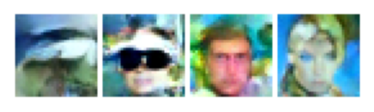

  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 20 | Loss: 0.04818721133737992 


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

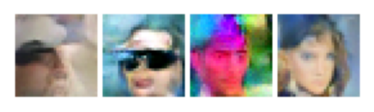

  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 21 | Loss: 0.04817256218729875 


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

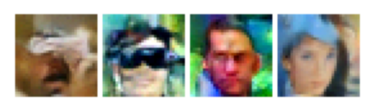

  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 22 | Loss: 0.04827443722826548 


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

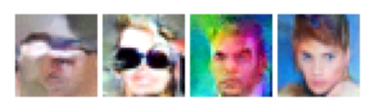

  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 23 | Loss: 0.04766463625889558 


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

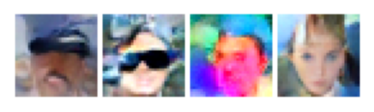

  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 24 | Loss: 0.04738655192538714 


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

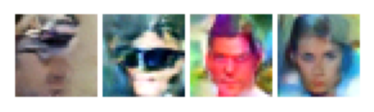

  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 25 | Loss: 0.047861045961960766 


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

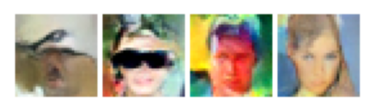

  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 26 | Loss: 0.04771036710112523 


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

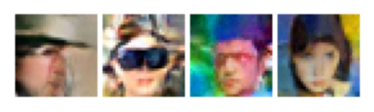

  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 27 | Loss: 0.047433323274629235 


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

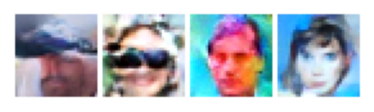

  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 28 | Loss: 0.047614788904021946 


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

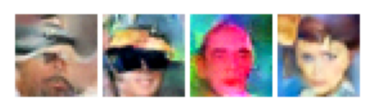

  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 29 | Loss: 0.04657579833307327 


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

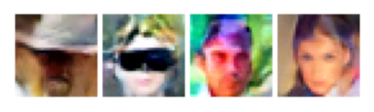

  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 30 | Loss: 0.04735544853103466 


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

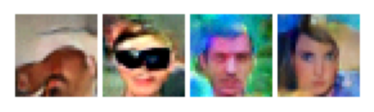

  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 31 | Loss: 0.04654671165805597 


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

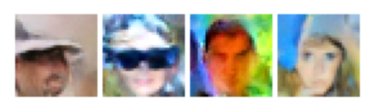

  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 32 | Loss: 0.04695953203795048 


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

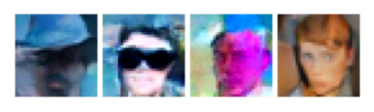

  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 33 | Loss: 0.04679832037251729 


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

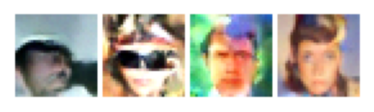

  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 34 | Loss: 0.0475770389326872 


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

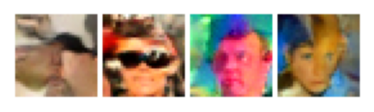

  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 35 | Loss: 0.04740848652063272 


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

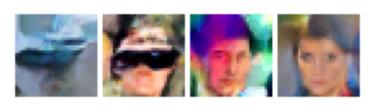

  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 36 | Loss: 0.046815497643099384 


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

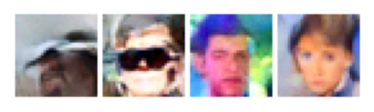

  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 37 | Loss: 0.04638147063744374 


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

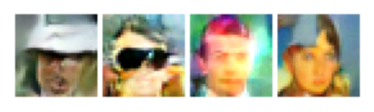

  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 38 | Loss: 0.0464538562278717 


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

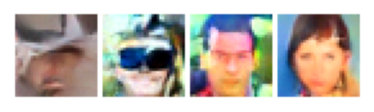

  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 39 | Loss: 0.0464891500532245 


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

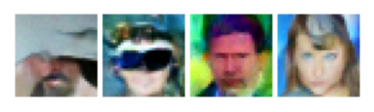

  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 40 | Loss: 0.04656239612839925 


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

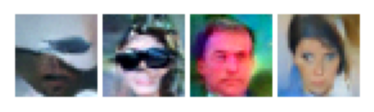

  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 41 | Loss: 0.04697692531805772 


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

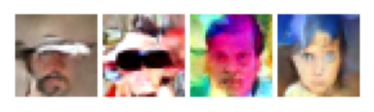

  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 42 | Loss: 0.04702322294410222 


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

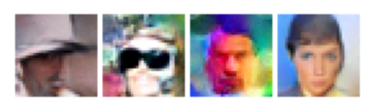

  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 43 | Loss: 0.04667466418005717 


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

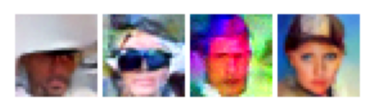

  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 44 | Loss: 0.04640085726307753 


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

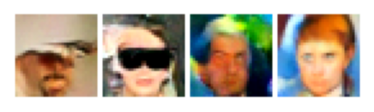

  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 45 | Loss: 0.04635004143302257 


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

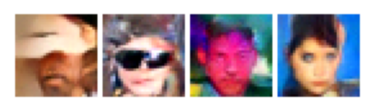

  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 46 | Loss: 0.0464177277416755 


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

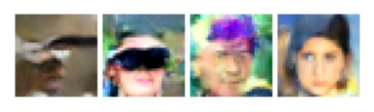

  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 47 | Loss: 0.04646178839298395 


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

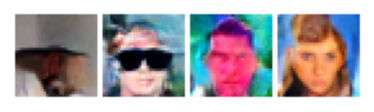

  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 48 | Loss: 0.046768615413934754 


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

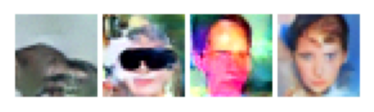

  0%|          | 0/390 [00:00<?, ?it/s]

Epoch 49 | Loss: 0.04642380467401101 


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

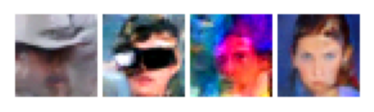

In [33]:
# Training loop
for epoch in range(epochs):
    model.train()
    losses = []

    for imgs, clip_desc in tqdm(faces_dataloader):
        imgs = imgs.to(device)
        clip_desc = clip_desc.to(device)
        optimizer.zero_grad()
        loss = model.training_step(imgs, clip_desc)
        loss.backward()
        optimizer.step()

    if epoch % 1 == 0:
        epoch_loss = np.mean(model.logs['train_loss'][-390:])
        print(f"Epoch {epoch} | Loss: {epoch_loss} ")

        # 1. Tokenize the strings using OpenAI CLIP
        text_tokens = clip.tokenize(text_list).to(device)

        # 2. Extract the embeddings and cast to float32
        with torch.no_grad():
            c_embeddings = clip_model.encode_text(text_tokens).float()

        # 3. Pass the TENSOR into the sampling function
        sampled_data = model.sample(c_embeddings, s=1.0)


        show_imgs(sampled_data)

# Save the model
torch.save(model.state_dict(), 'clip_faces.pth')

## Final evaluation

Generating images based on custom text...


Sampling (CFG):   0%|          | 0/300 [00:00<?, ?it/s]

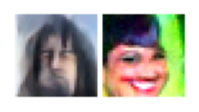

In [38]:
text_list_new = [
    "A sad man with long hair",
    "A smiling woman with green eyes",
]

text_tokens = clip.tokenize(text_list_new).to(device)

print("Generating images based on custom text...")
with torch.no_grad():
    c_new = clip_model.encode_text(text_tokens).float()

    sampled_data = model.sample(c_new, s=3.0)

show_imgs(sampled_data)

As promised, here are samples from a larger model trained over all the images of CelebA

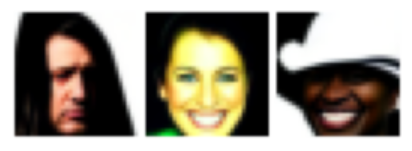